<a href="https://colab.research.google.com/github/shubhamraj8210/SkillCraft-ML-Internship/blob/main/Task_03_Cats_vs_Dogs_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

⏳ Downloading Cats vs Dogs dataset...
   (First time takes 2-3 min, ~800 MB)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.FTS2NV_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
✅ Dataset downloaded successfully!
   Total images: 23262

📥 Processing images...


Loading: 100%|██████████| 2326/2326 [00:02<00:00, 871.79it/s] 



✅ Total images loaded: 2326
   Feature size: 4096
   Cats (0): 1198, Dogs (1): 1128


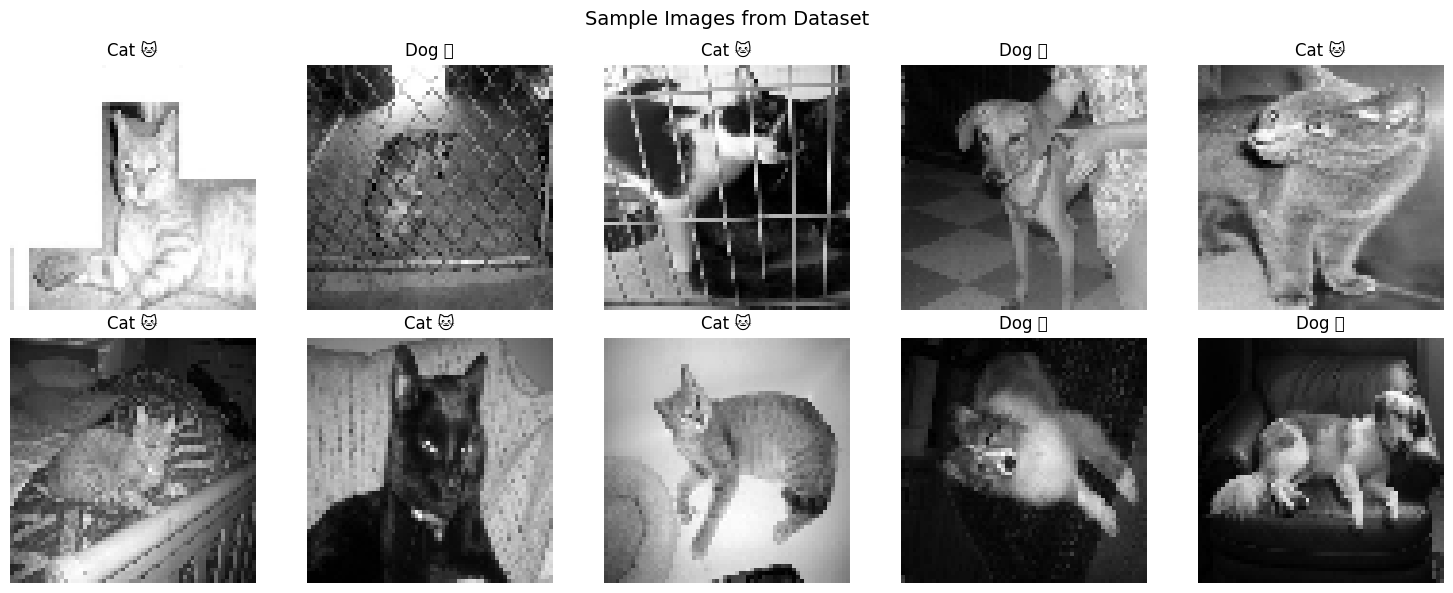


📊 Training set: (1860, 4096)
📊 Testing set : (466, 4096)

⏳ Training SVM model... (takes 2-5 minutes)
✅ Training complete!

🎯 Test Accuracy: 57.94%

📋 Classification Report:
              precision    recall  f1-score   support

         Cat       0.59      0.60      0.60       240
         Dog       0.57      0.56      0.56       226

    accuracy                           0.58       466
   macro avg       0.58      0.58      0.58       466
weighted avg       0.58      0.58      0.58       466



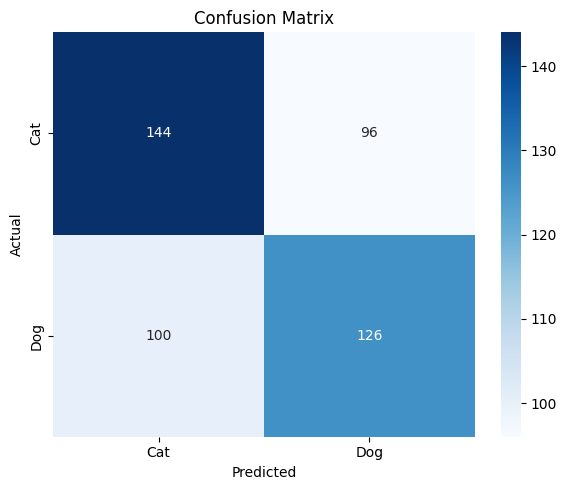

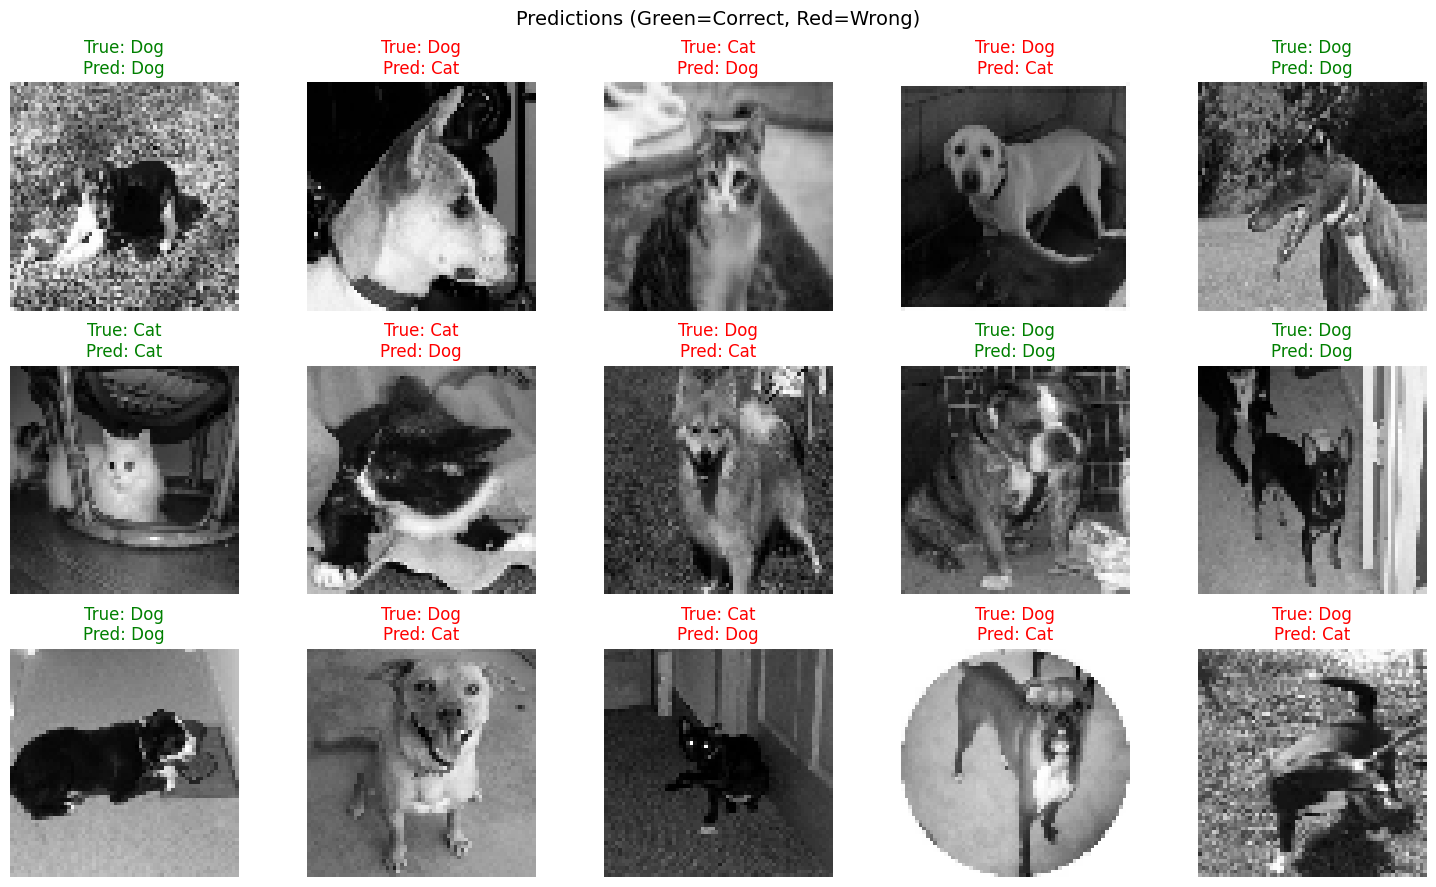


💾 Model saved as 'svm_cats_dogs_model.pkl'

🎉 Task 03 completed successfully!


In [4]:
# ============================================
# Task 03: Cats vs Dogs Classification using SVM
# Dataset: TensorFlow Datasets (Working Method)
# ============================================

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
import tensorflow_datasets as tfds
from tqdm import tqdm
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
import joblib
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. Download Dataset using TensorFlow Datasets
# ============================================
print("⏳ Downloading Cats vs Dogs dataset...")
print("   (First time takes 2-3 min, ~800 MB)")

# Load dataset
(ds_train,), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:10%]'],  # Using 10% (~2300 images) for faster training
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

print("✅ Dataset downloaded successfully!")
print(f"   Total images: {ds_info.splits['train'].num_examples}")

# ============================================
# 2. Convert to NumPy Arrays
# ============================================
IMG_SIZE = 64

print("\n📥 Processing images...")
X = []
y = []

for image, label in tqdm(tfds.as_numpy(ds_train), desc="Loading"):
    try:
        # Convert to grayscale
        img_gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        # Resize
        img_resized = cv2.resize(img_gray, (IMG_SIZE, IMG_SIZE))
        # Flatten
        X.append(img_resized.flatten())
        y.append(int(label))
    except Exception as e:
        continue

X = np.array(X)
y = np.array(y)

print(f"\n✅ Total images loaded: {X.shape[0]}")
print(f"   Feature size: {X.shape[1]}")
print(f"   Cats (0): {np.sum(y==0)}, Dogs (1): {np.sum(y==1)}")

# ============================================
# 3. Visualize Sample Images
# ============================================
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
indices = np.random.choice(len(X), 10, replace=False)

for ax, idx in zip(axes.ravel(), indices):
    img = X[idx].reshape(IMG_SIZE, IMG_SIZE)
    label = 'Cat 🐱' if y[idx] == 0 else 'Dog 🐶'
    ax.imshow(img, cmap='gray')
    ax.set_title(label)
    ax.axis('off')
plt.suptitle('Sample Images from Dataset', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# 4. Train-Test Split
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n📊 Training set: {X_train.shape}")
print(f"📊 Testing set : {X_test.shape}")

# ============================================
# 5. Build SVM Pipeline (Scaler + PCA + SVM)
# ============================================
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=150, whiten=True, random_state=42)),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42))
])

print("\n⏳ Training SVM model... (takes 2-5 minutes)")
pipeline.fit(X_train, y_train)
print("✅ Training complete!")

# ============================================
# 6. Evaluate the Model
# ============================================
y_pred = pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 50)
print(f"🎯 Test Accuracy: {accuracy * 100:.2f}%")
print("=" * 50)
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Cat', 'Dog']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ============================================
# 7. Visualize Predictions
# ============================================
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
sample_idx = np.random.choice(len(X_test), 15, replace=False)

for ax, idx in zip(axes.ravel(), sample_idx):
    img = X_test[idx].reshape(IMG_SIZE, IMG_SIZE)
    true_label = 'Cat' if y_test[idx] == 0 else 'Dog'
    pred_label = 'Cat' if y_pred[idx] == 0 else 'Dog'
    color = 'green' if true_label == pred_label else 'red'

    ax.imshow(img, cmap='gray')
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color)
    ax.axis('off')

plt.suptitle('Predictions (Green=Correct, Red=Wrong)', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# 8. Save the Model
# ============================================
joblib.dump(pipeline, 'svm_cats_dogs_model.pkl')
print("\n💾 Model saved as 'svm_cats_dogs_model.pkl'")

print("\n🎉 Task 03 completed successfully!")